In [5]:
import yaml
import numpy as np
from TraceSimulator import LongTraceSimulator
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from scipy.signal import fftconvolve
from OptimumFilter import *
from trace_IO import *


def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('/home/dwong/DELight_mtr/trigger_study/archive/wk11/config.yaml')
lts = LongTraceSimulator(config)


sampling_frequency = 3906250
vac_template = np.load("/home/dwong/DELight_mtr/trigger_study/wk15/templates/vac_ch_template.npy")
sub_template = np.load("/home/dwong/DELight_mtr/trigger_study/wk15/templates/sub_ch_template.npy")

noise_psd = np.load("/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy")
vac_of = OptimumFilter(vac_template, noise_psd, sampling_frequency)
sub_of = OptimumFilter(sub_template, noise_psd, sampling_frequency)



In [ ]:
trace, idx= lts.generate(
            E=30,
            x=-94, y=0, z=-1800,
            no_noise=False,
            type_recoil='NR',
            quantize=True,
            phonon_only=True,
            long_trace_samples = 250000
        )
trace = trace[0]

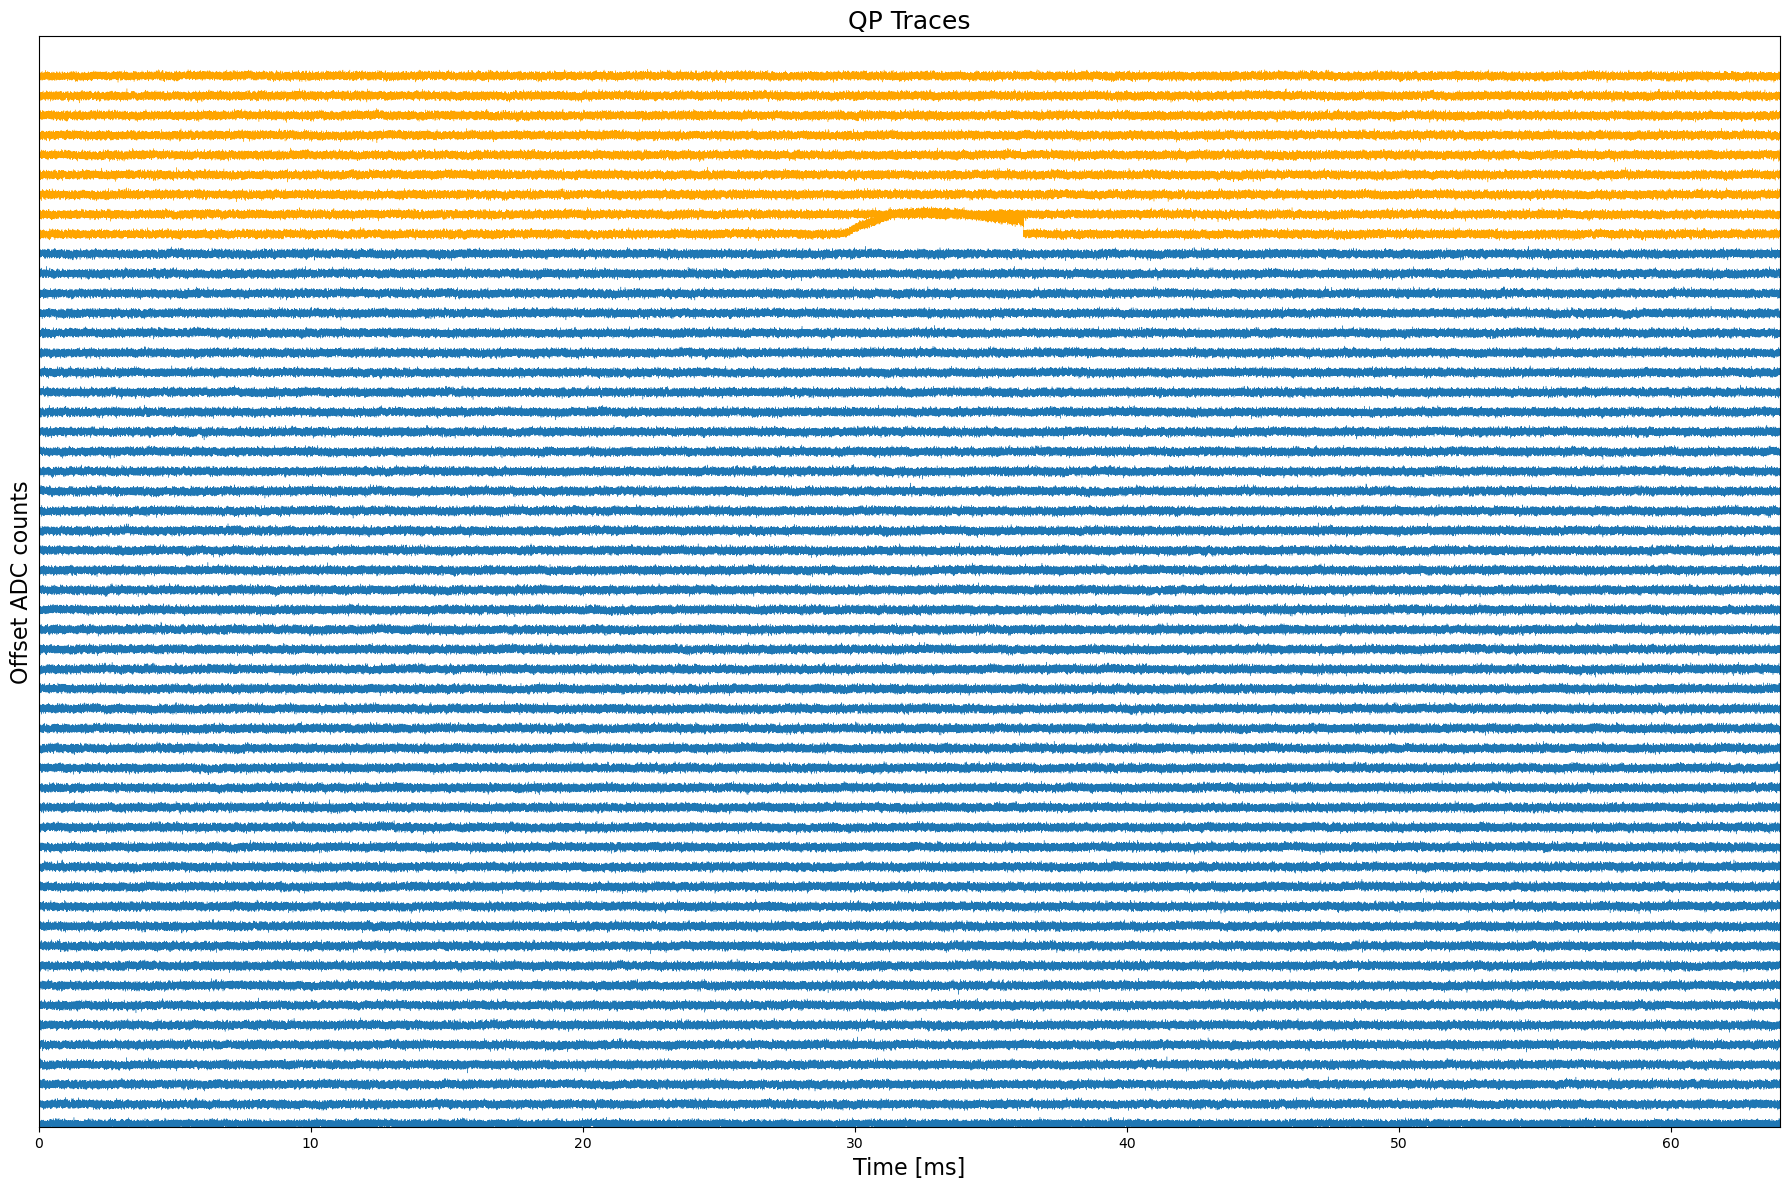

In [10]:
plot_traces(trace)

In [3]:
idx

108616

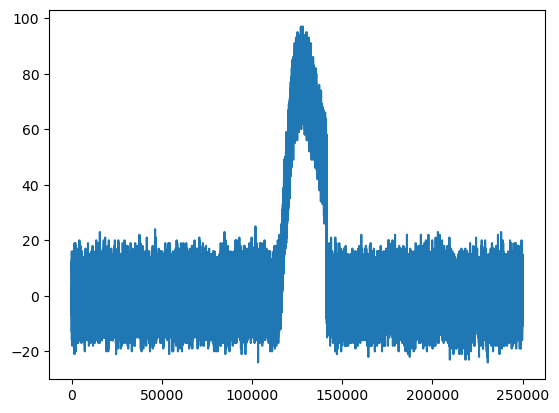

In [11]:
qp_example = trace[45]
plt.plot(qp_example)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

WIN = 32_768  # window length for vac_of.fit

# --- Run sliding-fit (your existing helper) ---
amps_slide, chisq_slide, starts_slide = vac_of.sliding_fit(qp_example, hop=1)

# --- Manual 1-sample sliding using vac_of.fit on fixed 32768-sample windows ---
N = len(qp_example)
if N < WIN:
    raise ValueError(f"Trace length ({N}) is smaller than window length ({WIN}).")

num_windows = N - WIN + 1
starts_fit = np.arange(num_windows)

amps_fit = np.empty(num_windows, dtype=float)
chisq_fit = np.empty(num_windows, dtype=float)

for i in tqdm(range(num_windows), desc="vac_of.fit sliding"):
    seg = qp_example[i:i+WIN]
    # vac_of.fit should return (amplitude, chisq). Adjust unpacking if your signature differs.
    a, c = vac_of.fit(seg)
    amps_fit[i] = a
    chisq_fit[i] = c

# --- Plot amplitude comparison ---
plt.figure(figsize=(12, 5))
plt.plot(starts_slide, amps_slide, label="Sliding-fit amplitude", lw=1.2)
plt.plot(starts_fit,  amps_fit,  label="vac_of.fit (window=32768, hop=1)", lw=1.2, linestyle='--')
plt.plot(qp_example, label="Raw trace", lw=0.8, alpha=0.5, color='gray')
plt.xlabel("Sample index (window start)")
plt.ylabel("Amplitude [A]")
plt.title("Optimum Filter Amplitude: sliding_fit vs vac_of.fit (32768, hop=1)")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot chi² comparison ---
plt.figure(figsize=(12, 5))
plt.plot(starts_slide, chisq_slide, label="Sliding-fit χ²", lw=1.2)
plt.plot(starts_fit,  chisq_fit,  label="vac_of.fit χ² (window=32768, hop=1)", lw=1.2, linestyle='--')
plt.plot(qp_example, label="Raw trace", lw=0.8, alpha=0.5, color='gray')
plt.xlabel("Sample index (window start)")
plt.ylabel("Reduced χ²")
plt.title("Optimum Filter χ²: sliding_fit vs vac_of.fit (32768, hop=1)")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


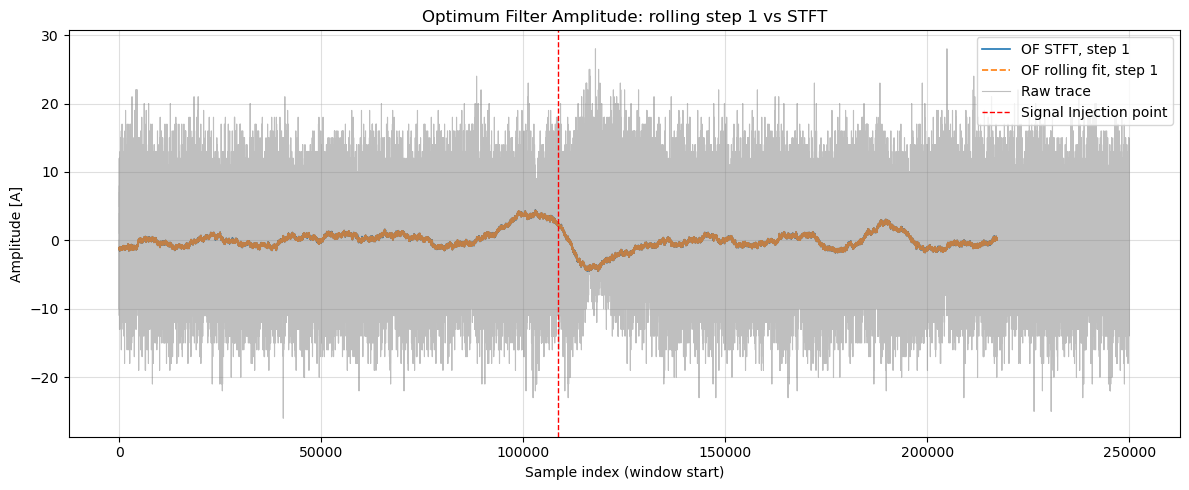

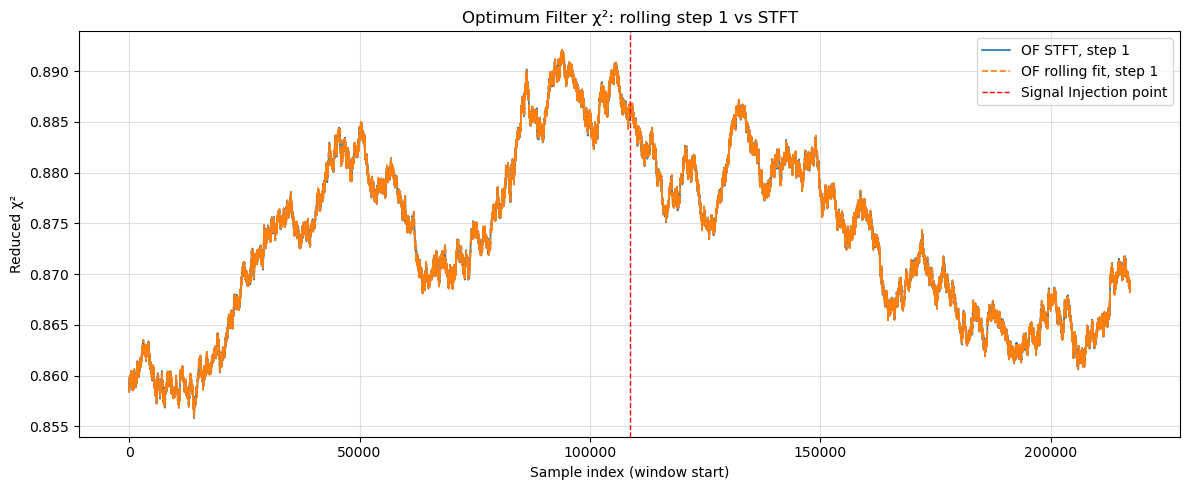

In [19]:
# --- Plot amplitude comparison ---
plt.figure(figsize=(12, 5))
plt.plot(starts_slide, amps_slide, label="OF STFT, step 1", lw=1.2)
plt.plot(starts_fit,  amps_fit,  label="OF rolling fit, step 1", lw=1.2, linestyle='--')
plt.plot(qp_example, label="Raw trace", lw=0.8, alpha=0.5, color='gray')
plt.xlabel("Sample index (window start)")
plt.ylabel("Amplitude [A]")
plt.title("Optimum Filter Amplitude: rolling step 1 vs STFT")
plt.axvline(idx, color='red', linestyle='--', linewidth=1, label="Signal Injection point")

plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot chi² comparison ---
plt.figure(figsize=(12, 5))
plt.plot(starts_slide, chisq_slide, label='OF STFT, step 1', lw=1.2)
plt.plot(starts_fit,  chisq_fit,  label="OF rolling fit, step 1", lw=1.2, linestyle='--')
plt.xlabel("Sample index (window start)")
plt.ylabel("Reduced χ²")
plt.title("Optimum Filter χ²: rolling step 1 vs STFT")
plt.axvline(idx, color='red', linestyle='--', linewidth=1, label="Signal Injection point")

plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

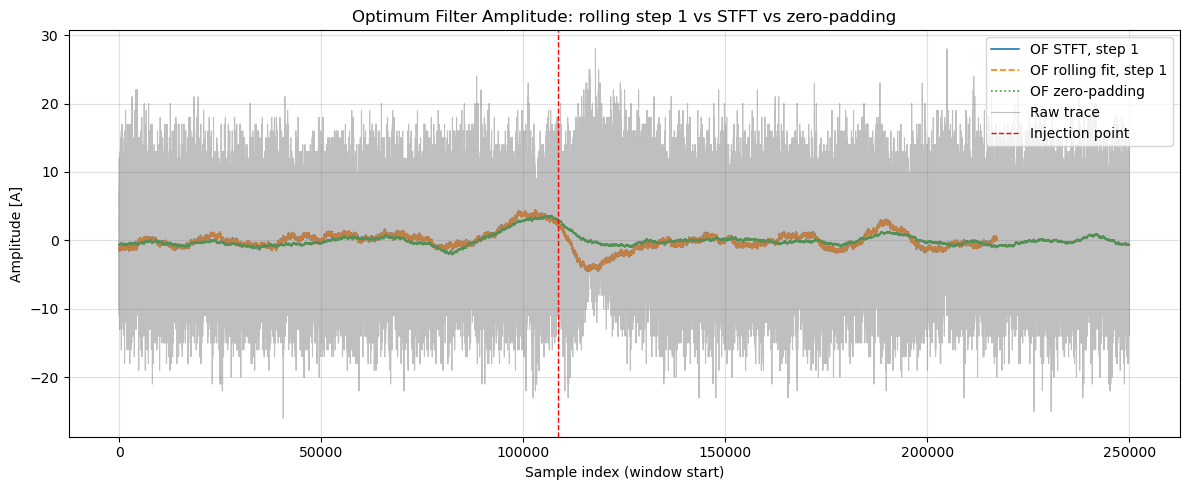

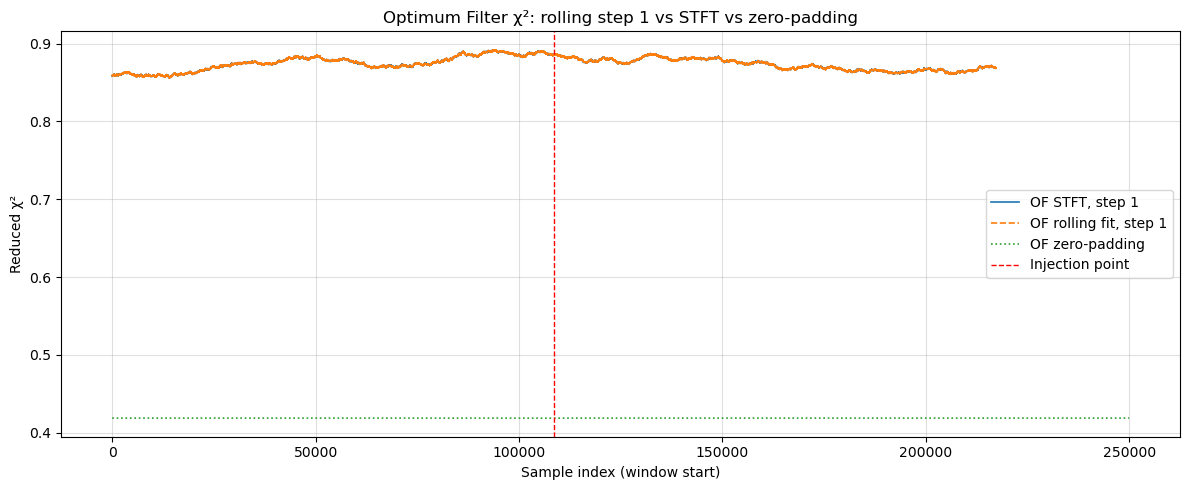

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes these are already computed/cached:
# qp_example, idx
# starts_slide, amps_slide, chisq_slide
# starts_fit,   amps_fit,  chisq_fit
amps_pad, chisq_pad = vac_of.padding_OF(qp_example)

# x-axes for the padding/global OF results
x_pad_amp  = np.arange(len(amps_pad))
x_pad_chi2 = np.arange(len(chisq_pad))

# --- Plot amplitude comparison ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(starts_slide, amps_slide, label="OF STFT, step 1", lw=1.2)
ax.plot(starts_fit,  amps_fit,  label="OF rolling fit, step 1", lw=1.2, linestyle='--')
ax.plot(x_pad_amp,   amps_pad,  label="OF zero-padding", lw=1.2, linestyle=':')
ax.plot(qp_example,  label="Raw trace", lw=0.8, alpha=0.5, color='gray')

# Red vertical line marking the injection point
inj_line = ax.axvline(idx, color='red', linestyle='--', linewidth=1, label="Injection point")

ax.set_xlabel("Sample index (window start)")
ax.set_ylabel("Amplitude [A]")
ax.set_title("Optimum Filter Amplitude: rolling step 1 vs STFT vs zero-padding")
ax.grid(True, alpha=0.4)

# Make sure the red vline appears in the legend (using the returned handle)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="best")

fig.tight_layout()
plt.show()

# --- Plot chi² comparison ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(starts_slide, chisq_slide, label="OF STFT, step 1", lw=1.2)
ax.plot(starts_fit,  chisq_fit,  label="OF rolling fit, step 1", lw=1.2, linestyle='--')
ax.plot(x_pad_chi2,  chisq_pad,  label="OF zero-padding", lw=1.2, linestyle=':')

# Red vertical line marking the injection point
inj_line = ax.axvline(idx, color='red', linestyle='--', linewidth=1, label="Injection point")

ax.set_xlabel("Sample index (window start)")
ax.set_ylabel("Reduced χ²")
ax.set_title("Optimum Filter χ²: rolling step 1 vs STFT vs zero-padding")
ax.grid(True, alpha=0.4)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="best")

fig.tight_layout()
plt.show()


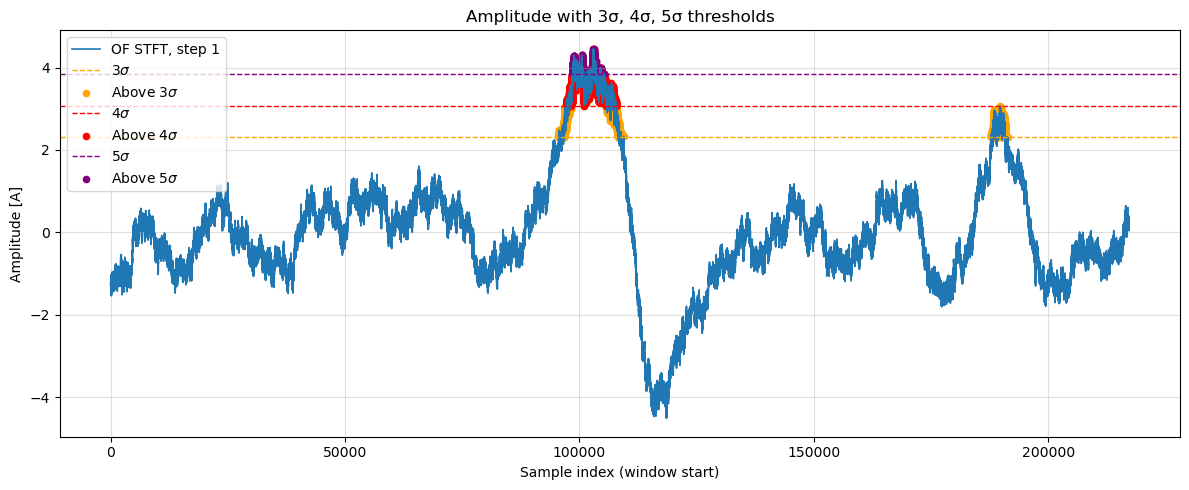

In [ ]:
bas

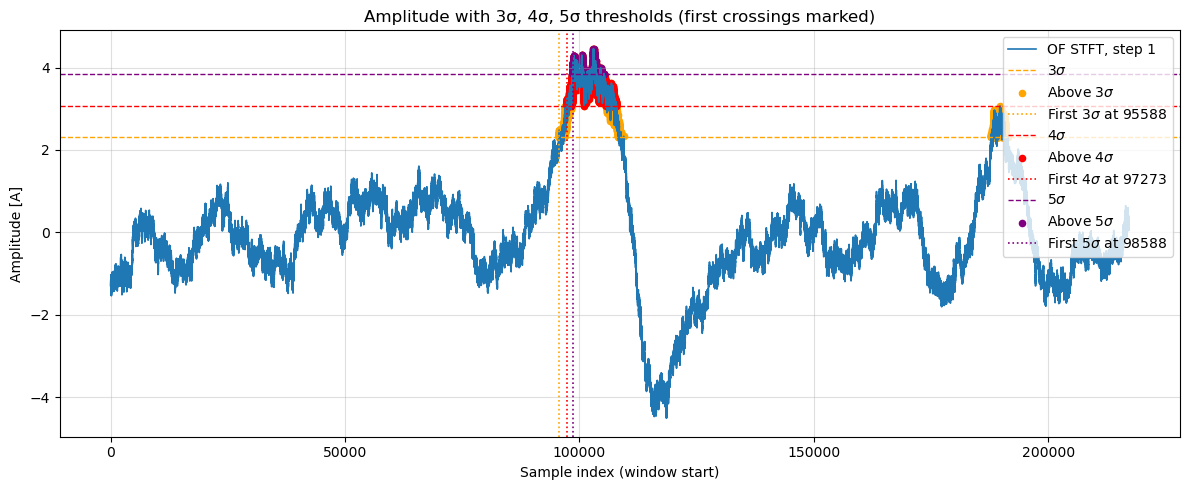

In [26]:
import numpy as np
import matplotlib.pyplot as plt

sigma = 0.7674
thresholds = [3*sigma, 4*sigma, 5*sigma]

# Boolean masks for each threshold
above_thresh = [(amps_slide > thr) for thr in thresholds]

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(starts_slide, amps_slide, label="OF STFT, step 1", lw=1.2)

# Mark thresholds and first-crossing points
colors = ['orange', 'red', 'purple']
for thr, mask, col, label in zip(thresholds, above_thresh, colors,
                                 [r"$3\sigma$", r"$4\sigma$", r"$5\sigma$"]):
    # Threshold line
    ax.axhline(thr, color=col, linestyle='--', lw=1, label=label)

    # Scatter all points above threshold
    ax.scatter(starts_slide[mask], amps_slide[mask],
               color=col, marker='o', s=20, label=f"Above {label}")

    # First index above threshold
    if np.any(mask):
        first_idx_pos = np.argmax(mask)  # first True position in mask
        first_x = starts_slide[first_idx_pos]
        ax.axvline(first_x, color=col, linestyle=':', lw=1.2,
                   label=f"First {label} at {first_x}")

ax.set_xlabel("Sample index (window start)")
ax.set_ylabel("Amplitude [A]")
ax.set_title("Amplitude with 3σ, 4σ, 5σ thresholds (first crossings marked)")
ax.grid(True, alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()


In [27]:
idx

108616

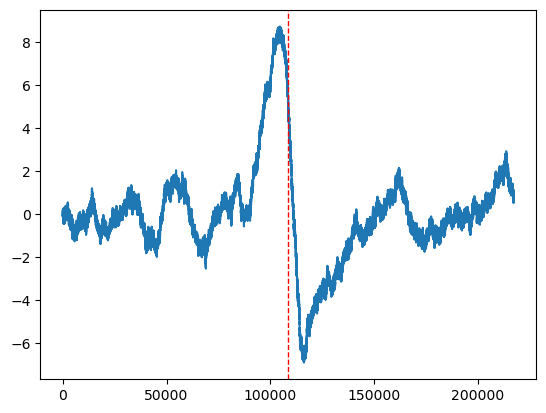

In [24]:
plt.plot(amps_slide)
plt.axvline(idx, color='red', linestyle='--', linewidth=1)  # vertical line
plt.show()


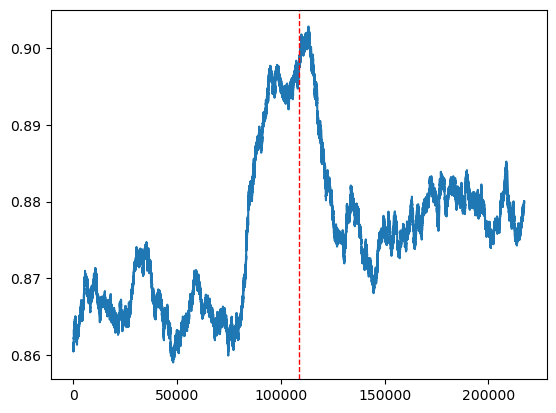

In [23]:
plt.plot(chisq_slide)
plt.axvline(idx, color='red', linestyle='--', linewidth=1)  # vertical line
plt.show()


In [20]:
idx

108616

In [14]:
np.savez("validation_trace.npz", raw=example, ampl=np_result, inject=idx)


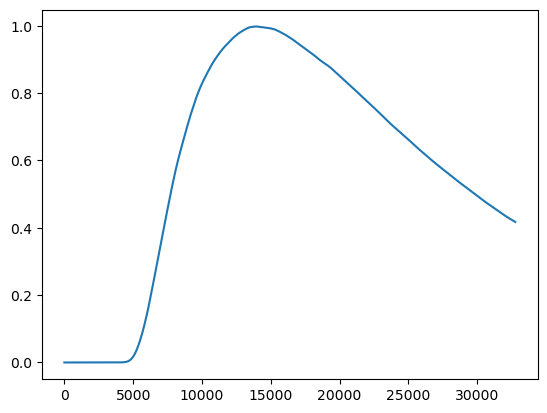

In [21]:
plt.plot(vac_template)